<!-- FULL: keep, DEMO: keep -->
<div style='display:flex; align-items:center; justify-content:space-between; border-bottom:3px solid rgb(255,106,0); padding-bottom:1em;'>
<div>
<span style='color:rgb(22,60,105); font-size:1.8em; font-weight:bold;'>Introduction to Deep Learning</span><br>
<span style='color:rgb(0,85,100); font-size:1.3em;'>Session 6 &mdash; 2: Training Loop from Scratch</span><br>
<span style='color:rgb(0,85,100); font-size:1.0em;'>Magda Gregorová &nbsp;·&nbsp; THWS &nbsp;·&nbsp; May 2026</span>
</div>
<img src='../../Common/Pics/thws-logo_vert_en_orange-rgb.png' style='height:80px;'/>
</div>

<!-- FULL: keep, DEMO: delete -->
We have tensors, autograd, and gradients. Now let's use them to actually train — no `torch.nn`, no `torch.optim`. Just the raw update rule from Session 5.

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import sys

# path to assignment 1
assignment_path = '../../Assignment_1/'
sys.path.append(assignment_path)
from helpers import load_data

X, y = load_data(assignment_path+'data.csv')


<!-- FULL: keep, DEMO: keep -->
<div style='margin:2em 0 0.5em 0; padding:0.4em 0.8em; border-left:5px solid rgb(255,106,0); background:rgb(240,244,248); color:rgb(22,60,105); font-size:1.1em; font-weight:bold;'>
  Setup — parameters and data
</div>

<!-- FULL: keep, DEMO: delete -->
Same decomposition as before — linear regression on the housing data.

We use only the first feature (`size`) for clarity, keeping it truly 1D.

Parameters initialised to zero — we will watch them move during training.

In [3]:
# use a single feature for clarity
X_train = X[:, 1:2]   # size feature only, shape (N, 1)
y_train = y           # shape (N, 1)

# parameters — initialised to zero
theta_1 = torch.zeros(1, 1, requires_grad=True)   # weight shape (1, 1)
theta_0 = torch.zeros(1, 1, requires_grad=True)   # bias   shape (1, 1)

print(f'theta_1: {theta_1.item():.4f}')
print(f'theta_0: {theta_0.item():.4f}')


theta_1: 0.0000
theta_0: 0.0000


<!-- FULL: keep, DEMO: keep -->
<div style='margin:2em 0 0.5em 0; padding:0.4em 0.8em; border-left:5px solid rgb(255,106,0); background:rgb(240,244,248); color:rgb(22,60,105); font-size:1.1em; font-weight:bold;'>
  Manual SGD training loop
</div>

<!-- FULL: keep, DEMO: delete -->
The update rule from Session 5:

$$\\theta \\leftarrow \\theta - \\eta \\, \\nabla_{\\theta} L$$

We implement it directly:
1. Forward pass
2. Compute loss
3. `.backward()` — fills `.grad`
4. Update with `torch.no_grad()` — parameters must not be tracked
5. Zero gradients

Note `torch.no_grad()` wrapping the update — without it, the update step itself would be recorded in the computation graph.

In [4]:
lr       = 0.1
n_epochs = 50
losses   = []

for epoch in range(n_epochs):

    # 1 & 2 — forward pass and loss
    yhat = X_train @ theta_1.T + theta_0   # shape (N, 1)
    z    = yhat - y_train
    L    = (z ** 2).mean()
    losses.append(L.item())

    # 3 — backward
    L.backward()

    # 4 — update (no_grad: update must not be part of the graph)
    with torch.no_grad():
        theta_1 -= lr * theta_1.grad
        theta_0 -= lr * theta_0.grad

    # 5 — zero gradients
    theta_1.grad.zero_()
    theta_0.grad.zero_()

print(f'Final loss:    {losses[-1]:.4f}')
print(f'theta_1: {theta_1.item():.4f}')
print(f'theta_0: {theta_0.item():.4f}')


Final loss:    0.2249
theta_1: 0.8801
theta_0: -0.0000


<!-- FULL: keep, DEMO: keep -->
<div style='margin:2em 0 0.5em 0; padding:0.4em 0.8em; border-left:5px solid rgb(255,106,0); background:rgb(240,244,248); color:rgb(22,60,105); font-size:1.1em; font-weight:bold;'>
  Loss curve
</div>

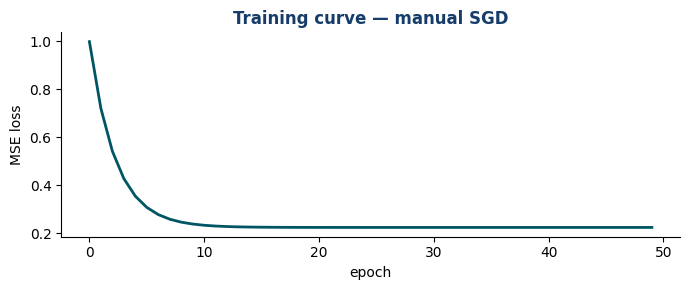

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses, color='#005564', linewidth=2)
ax.set_xlabel('epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Training curve — manual SGD', color='#163C69', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


<!-- FULL: keep, DEMO: delete -->
<div style='margin:2em 0 0.5em 0; padding:0.4em 0.8em; border-left:5px solid rgb(255,106,0); background:rgb(240,244,248); color:rgb(22,60,105); font-size:1.1em; font-weight:bold;'>
  Fit visualisation
</div>

<!-- FULL: keep, DEMO: delete -->
Plot the learned line against the data.

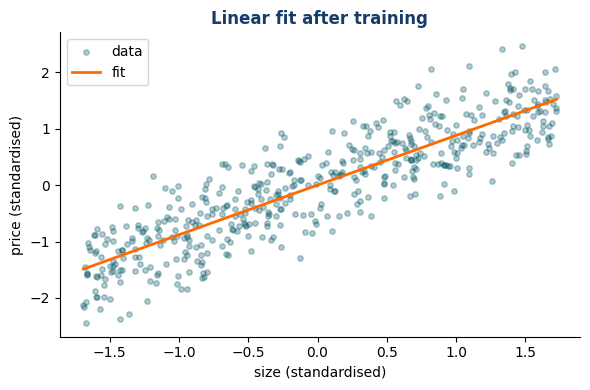

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train.numpy(), y_train.numpy(),
           alpha=0.3, s=15, color='#005564', label='data')

x_line = torch.linspace(X_train.min(), X_train.max(), 100).unsqueeze(1)
with torch.no_grad():
    y_line = x_line @ theta_1.T + theta_0
ax.plot(x_line.numpy(), y_line.numpy(),
        color='#FF6A00', linewidth=2, label='fit')

ax.set_xlabel('size (standardised)')
ax.set_ylabel('price (standardised)')
ax.set_title('Linear fit after training', color='#163C69', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


<!-- FULL: keep, DEMO: delete -->
<div style='margin:2em 0 0.5em 0; padding:0.4em 0.8em; border-left:5px solid rgb(255,106,0); background:rgb(240,244,248); color:rgb(22,60,105); font-size:1.1em; font-weight:bold;'>
  What this loop is missing
</div>

<!-- FULL: keep, DEMO: delete -->
This loop works but is limited:

- **Full-batch** — uses all data every step; slow for large datasets
- **Manual parameter management** — error-prone as networks grow
- **No validation** — no way to detect overfitting
- **Hard-coded SGD** — to use Adam, momentum etc. we'd rewrite the update

`nn.Module`, `DataLoader`, and `torch.optim` solve all of these — covered in the next notebooks.